<a href="https://colab.research.google.com/github/wpalmas/CAD-VUS-Analysis/blob/main/VUS_Analysis_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VUS Analysis — Google Colab Notebook

This notebook runs the complete VUS analysis from the paper.
**No installation needed beyond this cell.**

## Instructions
1. Upload the `CAD_VUS_Analysis_Final.zip` file when prompted (Cell 1)
2. Run all cells in order (Runtime → Run all)
3. Figures and results appear inline and are saved to `outputs/`

In [ ]:
# ── Cell 1: Upload and unzip the repository ──────────────────────────────────
from google.colab import files
import zipfile, os, sys

print('Please upload CAD_VUS_Analysis_Final.zip ...')
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('.')

# Find the repo root (the extracted folder)
repo = 'vus_repo_final'
sys.path.insert(0, os.path.join(repo, 'src'))
os.makedirs(os.path.join(repo, 'outputs'), exist_ok=True)
print(f'Repository ready: {repo}/')
print('Files:', sorted(os.listdir(repo)))

Please upload CAD_VUS_Analysis_Final.zip ...


Saving CAD_VUS_Analysis_Final_3.zip to CAD_VUS_Analysis_Final_3 (1).zip
Repository ready: vus_repo_final/
Files: ['README.md', 'VUS_Analysis_Colab.ipynb', 'data', 'outputs', 'requirements.txt', 'run_example.py', 'src', 'stan']


In [ ]:
# ── Cell 2: Install dependencies (already available in Colab) ────────────────
# numpy, pandas, scipy, scikit-learn, matplotlib are all pre-installed in Colab
# This cell just confirms everything is present
import numpy, pandas, scipy, sklearn, matplotlib
print('numpy:', numpy.__version__)
print('pandas:', pandas.__version__)
print('scipy:', scipy.__version__)
print('sklearn:', sklearn.__version__)
print('matplotlib:', matplotlib.__version__)
print('All dependencies OK')

numpy: 2.0.2
pandas: 2.2.2
scipy: 1.16.3
sklearn: 1.6.1
matplotlib: 3.10.0
All dependencies OK


In [ ]:
# ── Cell 3: Run the simulations (produces results.json) ──────────────────────
# This takes about 5-10 minutes with 1000 bootstrap draws.
# Reduce N_BOOT below for a quick test (try 100 first).
import subprocess, sys
result = subprocess.run(
    [sys.executable, os.path.join(repo, 'src', 'run_simulations.py')],
    capture_output=True, text=True
)
print(result.stdout[-3000:])   # show last 3000 chars of output
if result.returncode != 0:
    print('ERRORS:', result.stderr[-1000:])

Region tiling: OK

Point estimates:
  Test1 VUS=0.8008 (estimable)
  Test2 VUS=0.7573 (estimable)
  TestA VUS=0.8008 (estimable)
  TestB VUS: Global VUS cannot be estimated: observed range [34, 59] cove
    TestB PVUS Mild (0–22): n/e (0 grid pts)
    TestB PVUS Intermediate (23–32): n/e (0 grid pts)
    TestB PVUS Severe (≥33): 0.8804 (22 grid pts)

Bootstrapping Simulation 1 (paired)...
    draw 0/1000...
    draw 200/1000...
    draw 400/1000...
    draw 600/1000...
    draw 800/1000...

=== Simulation 1: Paired ===
  VUS:    T1=0.806 [0.779, 0.834]  T2=0.762 [0.732, 0.792]
  dVUS:   0.044 [0.040, 0.049]  P(T1>T2)=1.000
  SGI:    T1=36.8% [27.9%, 44.9%]  T2=33.7% [23.7%, 42.7%]
  Mild (0–22):
    T1=0.717 [0.670, 0.760]  T2=0.684 [0.636, 0.728]
    dPVUS=0.033 [0.030, 0.037]  P(T1>T2)=1.000
  Intermediate (23–32):
    T1=0.843 [0.808, 0.875]  T2=0.790 [0.749, 0.827]
    dPVUS=0.054 [0.047, 0.061]  P(T1>T2)=1.000
  Severe (≥33):
    T1=0.922 [0.893, 0.948]  T2=0.868 [0.827, 0.905]
  

In [ ]:
# ── Cell 4: Generate all figures ─────────────────────────────────────────────
import matplotlib
matplotlib.use('Agg')   # non-interactive backend for Colab
import matplotlib.pyplot as plt

result2 = subprocess.run(
    [sys.executable, os.path.join(repo, 'src', 'make_figures.py')],
    capture_output=True, text=True
)
print(result2.stdout)
if result2.returncode != 0:
    print('ERRORS:', result2.stderr[-1000:])

  fig1_sim1_domes.png saved.
  fig2_sim2_naive_roc.png saved.
  fig3_sim2_domes.png saved.
  fig4_auc_profiles.png saved.

All figures saved.




--- fig0_syntax_distribution.png ---


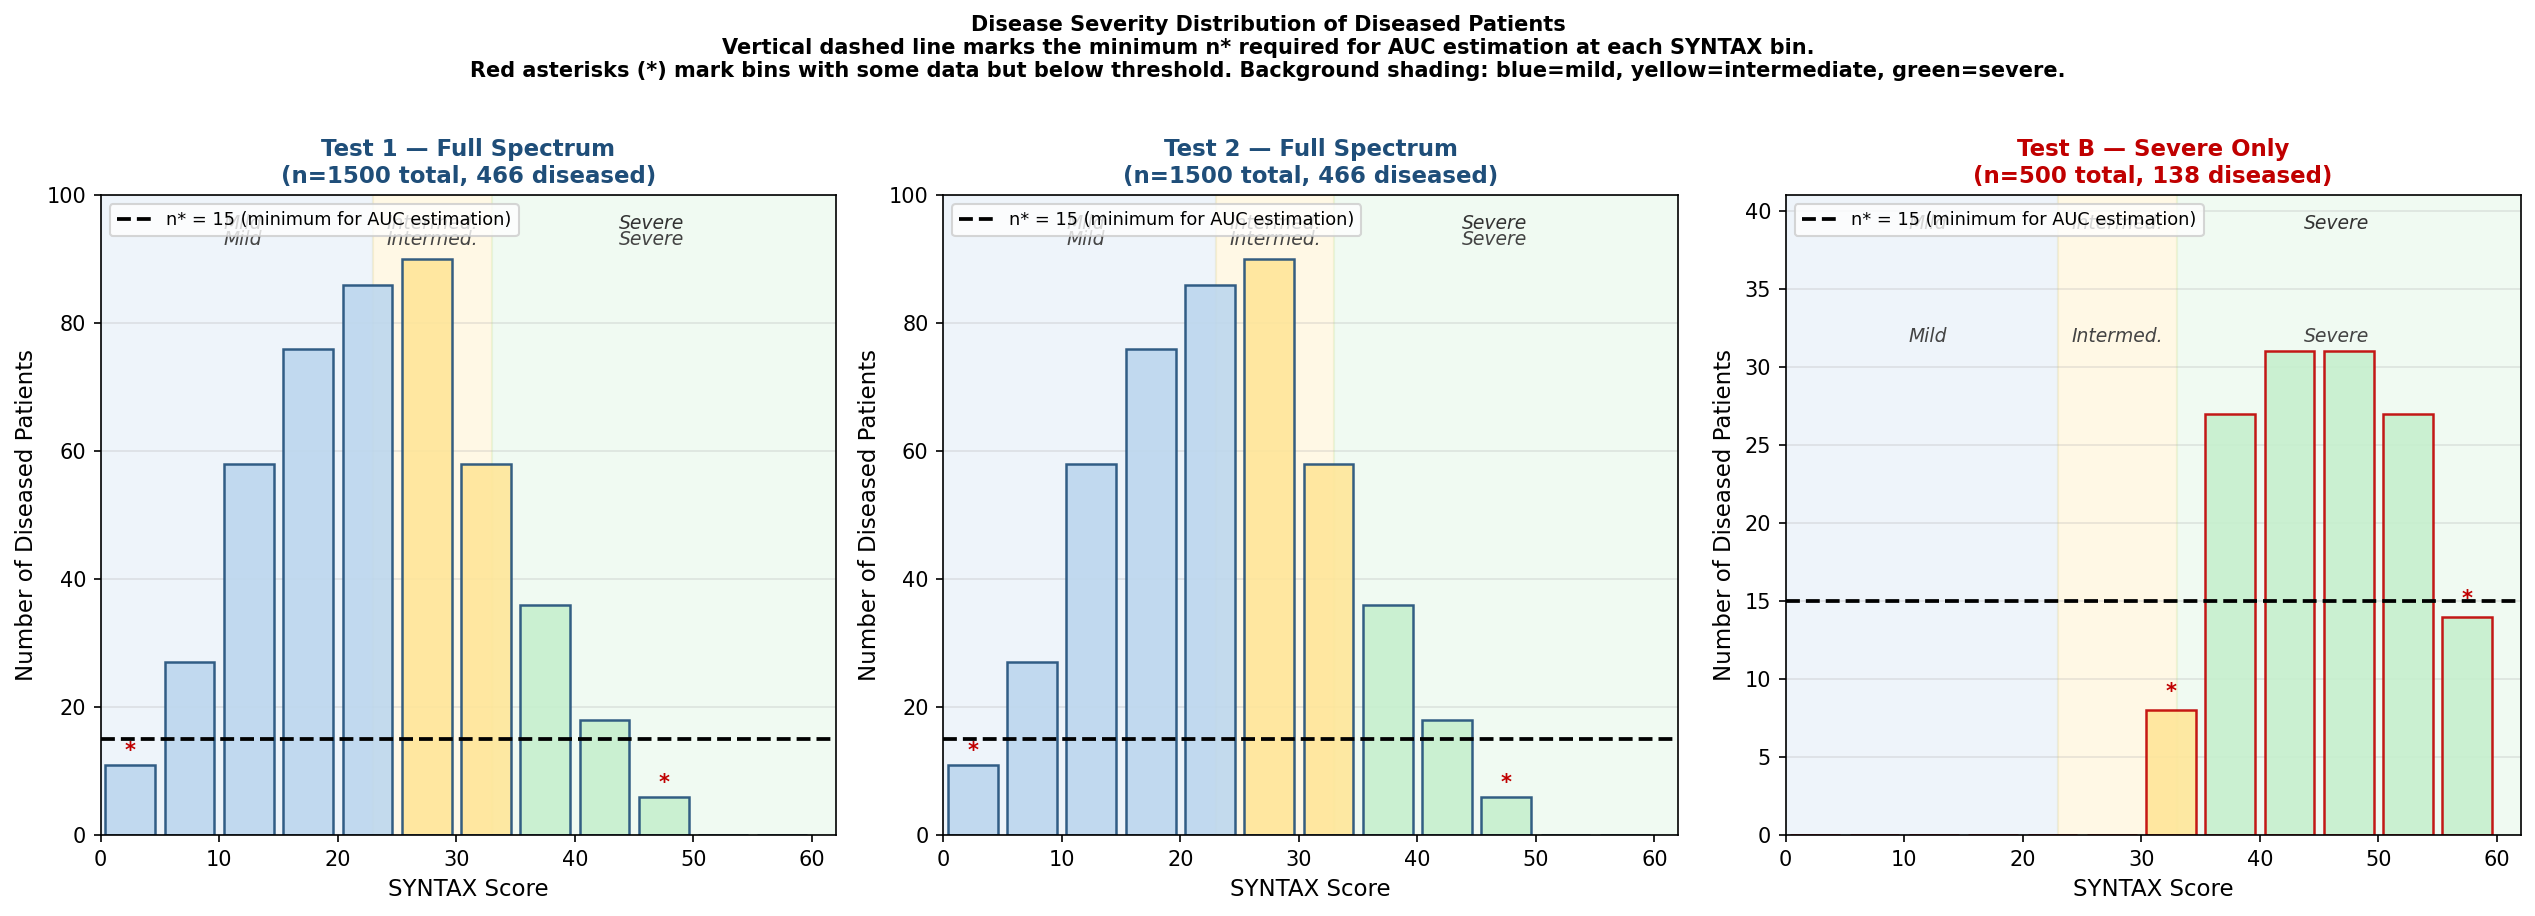


--- fig1_sim1_domes.png ---


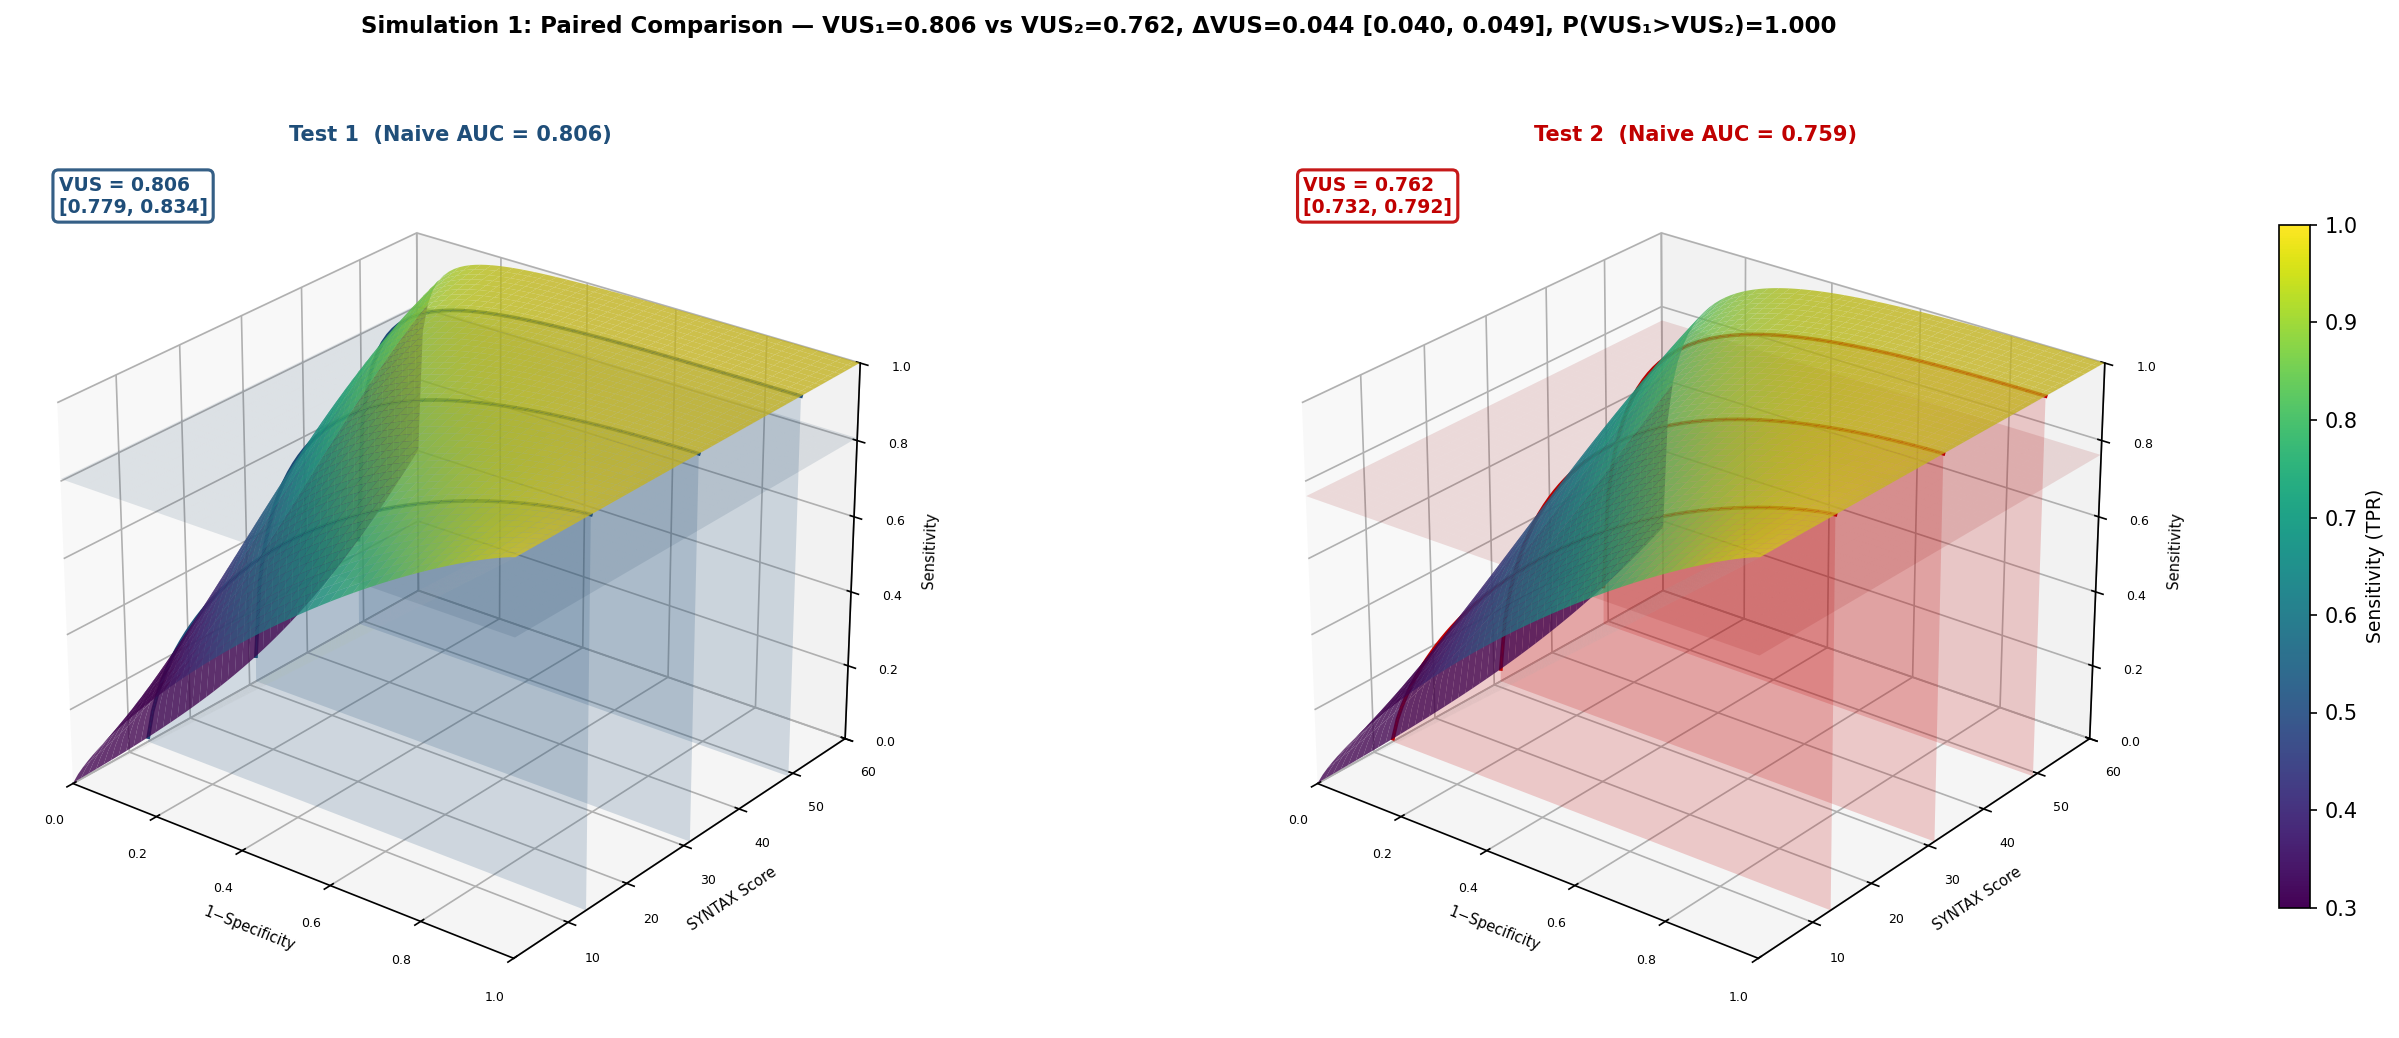


--- fig2_sim2_naive_roc.png ---


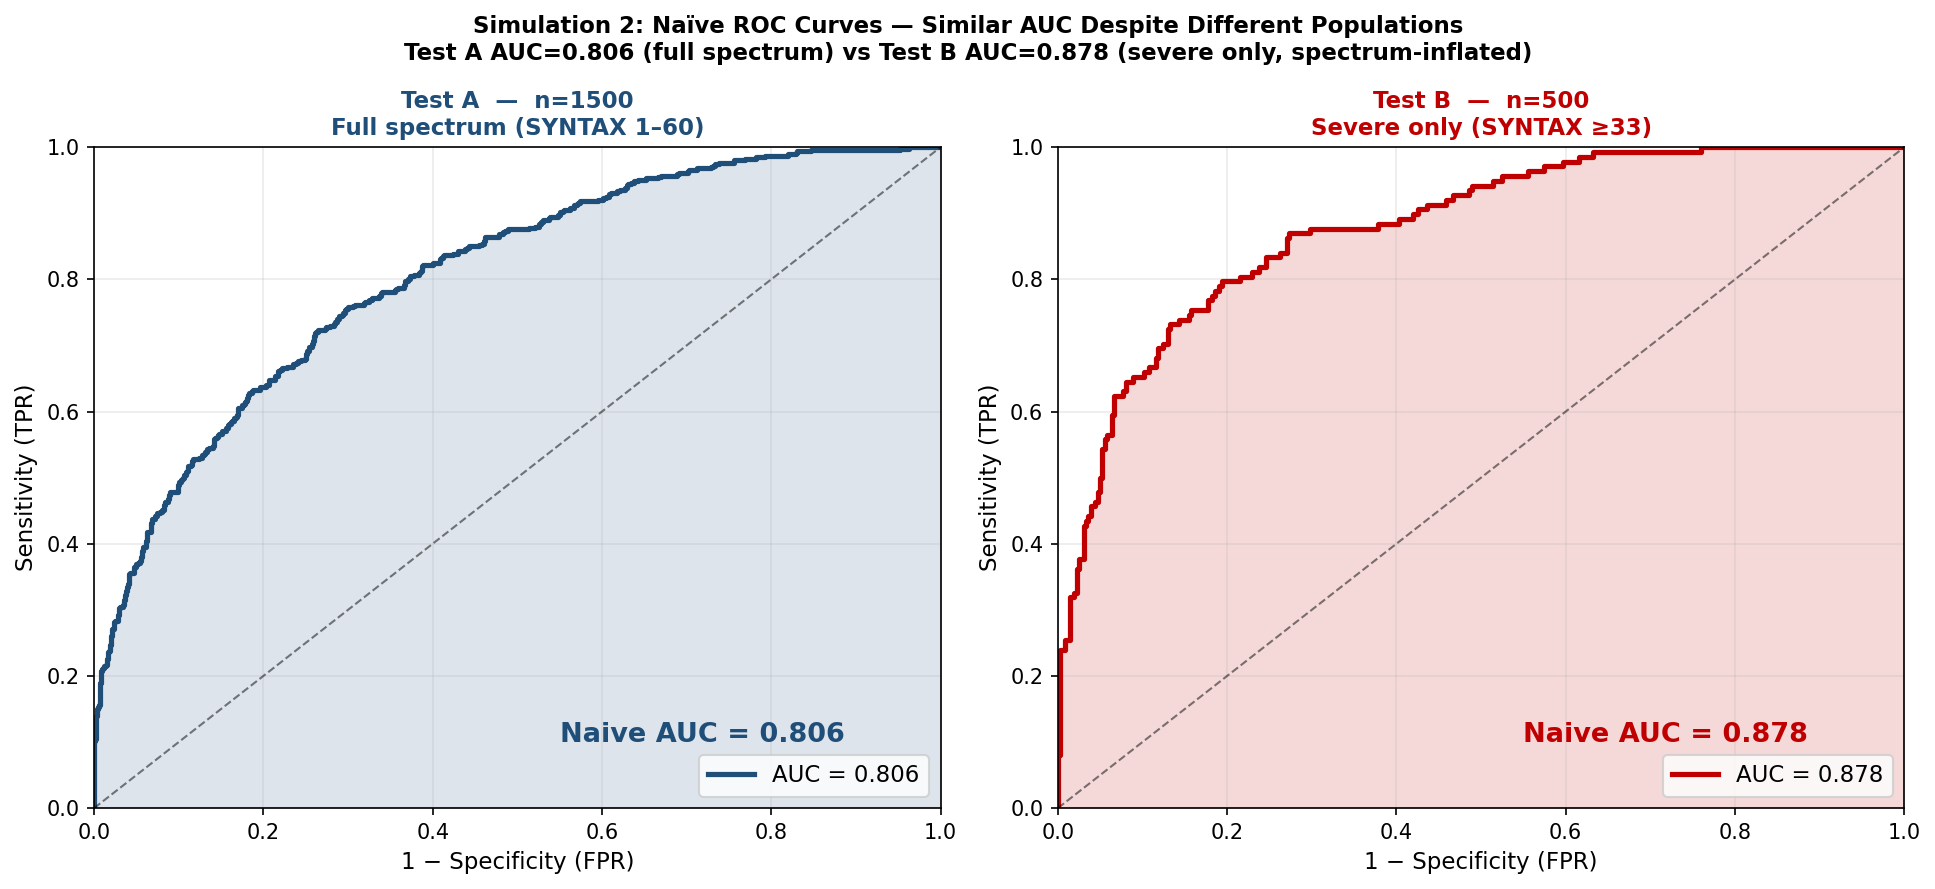


--- fig3_sim2_domes.png ---


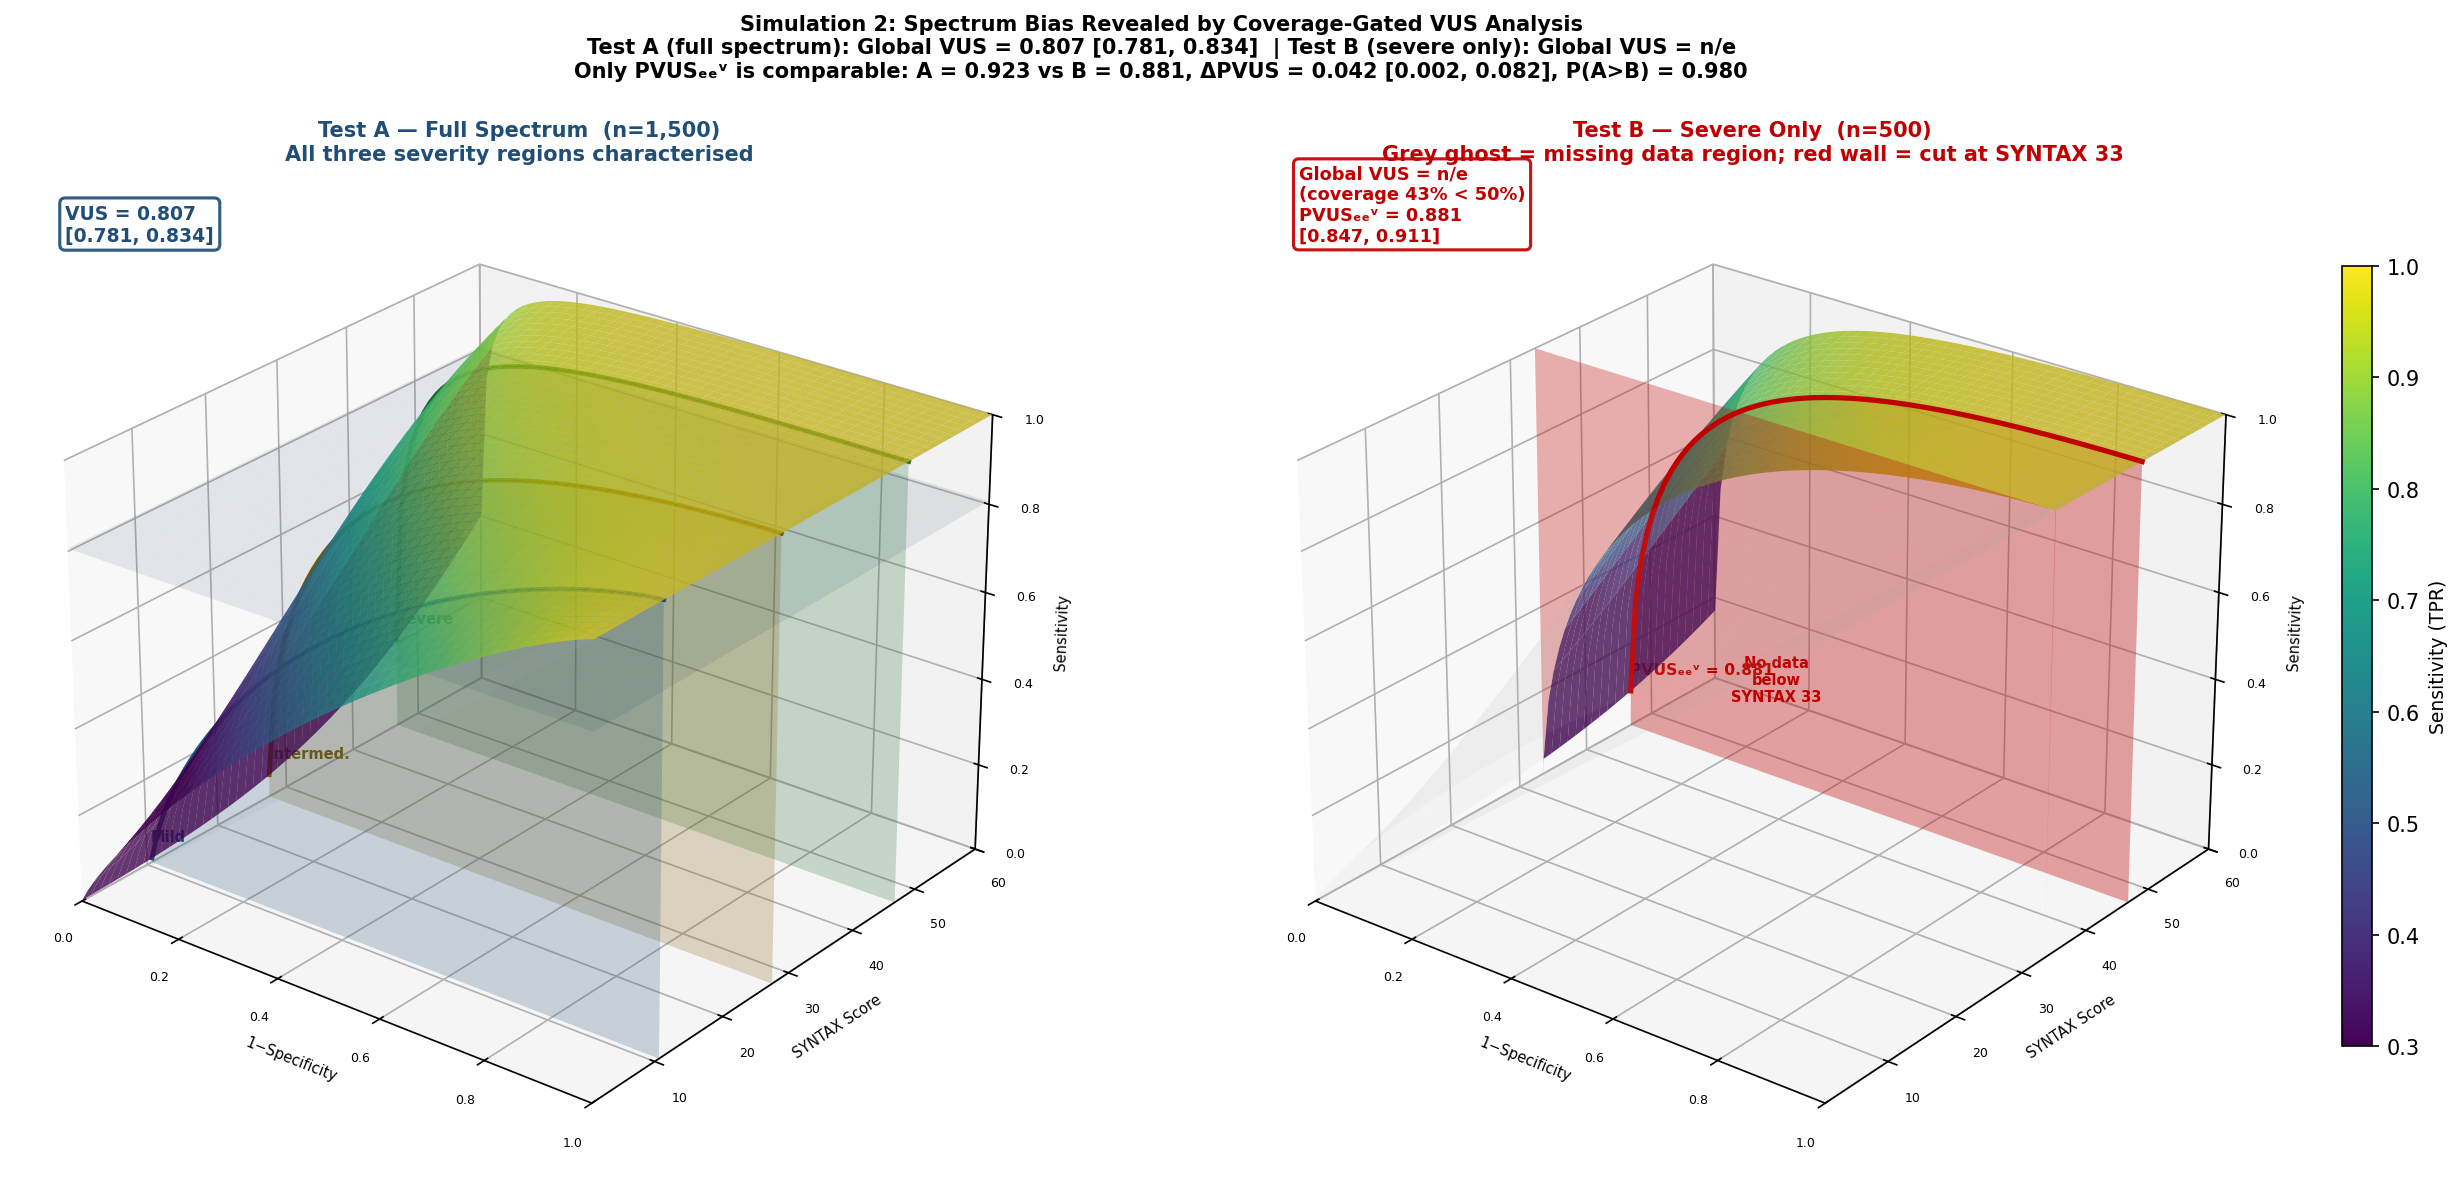


--- fig4_auc_profiles.png ---


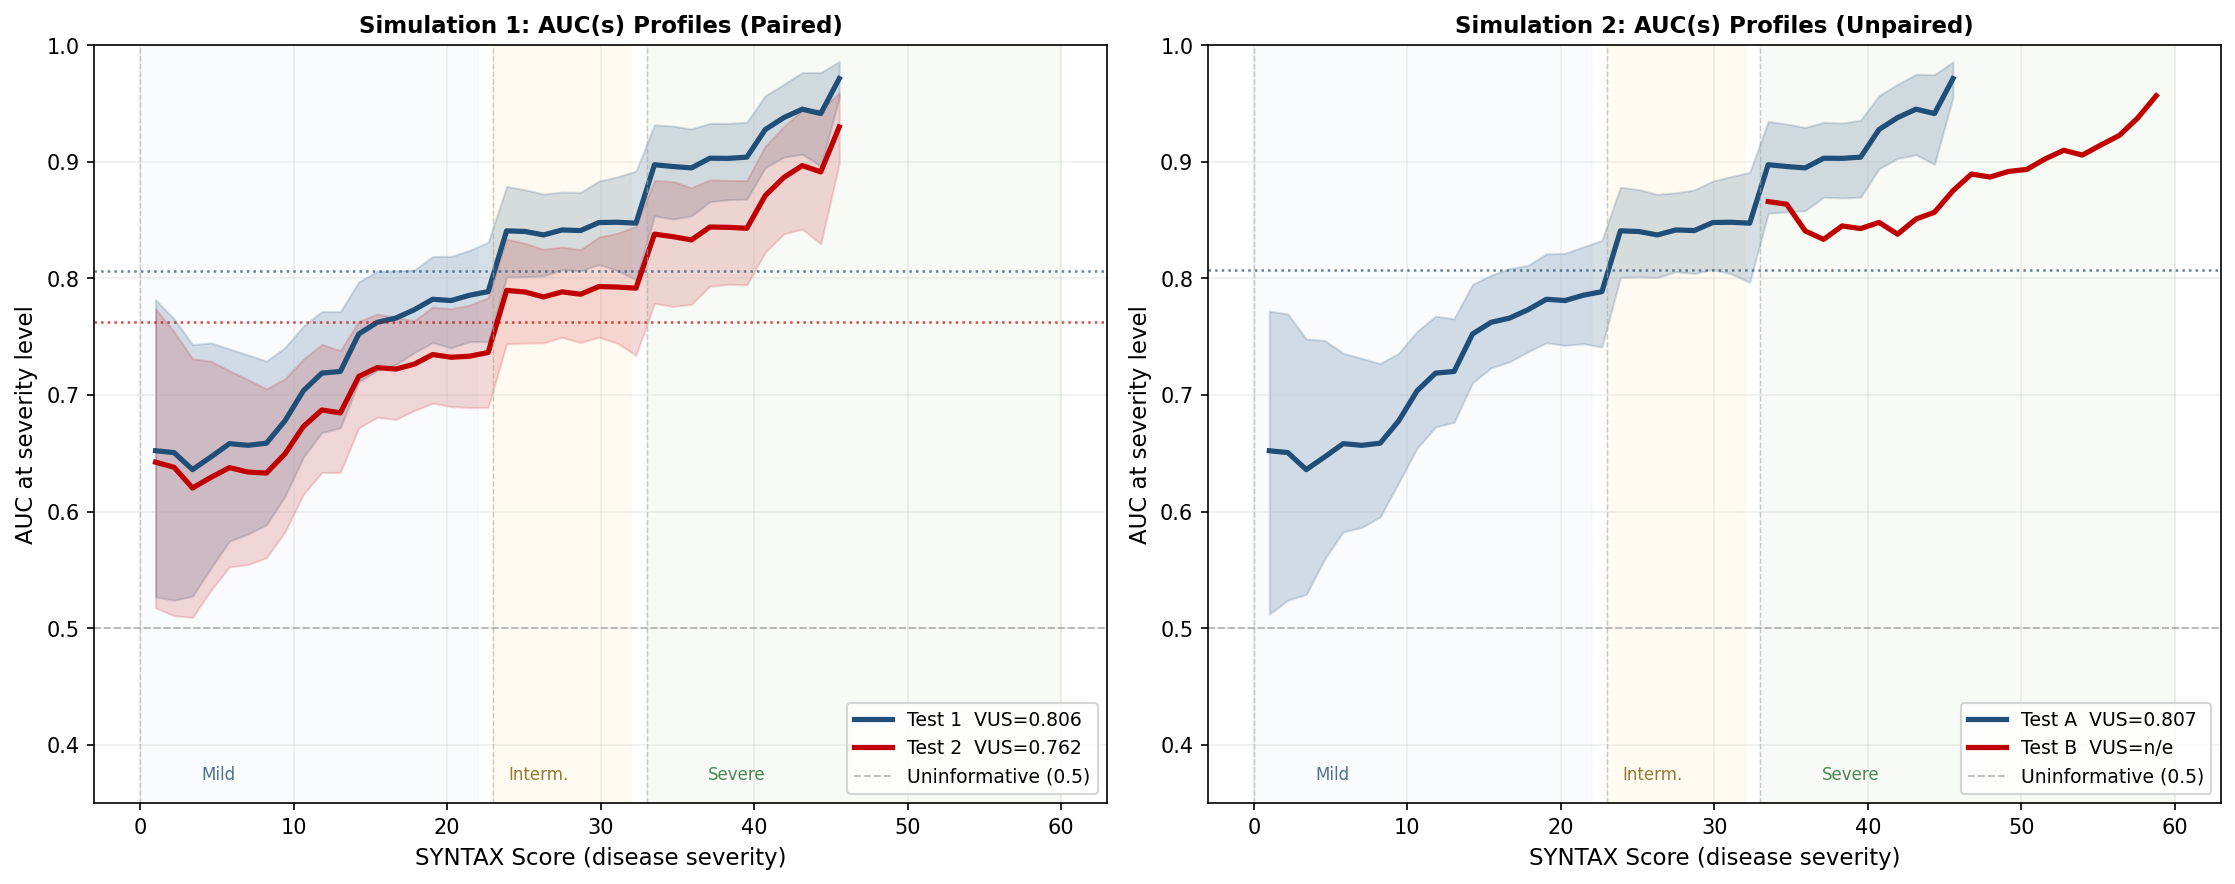

In [ ]:
# ── Cell 5: Display all figures inline ───────────────────────────────────────
from IPython.display import Image, display
import glob

figs = sorted(glob.glob(os.path.join(repo, 'outputs', 'fig*.png')))
for f in figs:
    print(f'\n--- {os.path.basename(f)} ---')
    display(Image(f, width=900))

In [ ]:
# ── Cell 6: Print results summary ────────────────────────────────────────────
import json
R = json.load(open(os.path.join(repo, 'outputs', 'results.json')))
s1 = R['sim1']; s2 = R['sim2']

def fmt(m, lo, hi, pct=False):
    if m is None: return 'n/e'
    if pct: return f'{m*100:.1f}% [{lo*100:.1f}%, {hi*100:.1f}%]'
    return f'{m:.3f} [{lo:.3f}, {hi:.3f}]'

print('='*60)
print('SIMULATION 1: PAIRED COMPARISON')
print('='*60)
print(f'  Naive AUC T1: {s1["nauc1"]:.3f}  T2: {s1["nauc2"]:.3f}')
print(f'  Global VUS T1: {fmt(s1["vus1"],s1["vus1_lo"],s1["vus1_hi"])}')
print(f'  Global VUS T2: {fmt(s1["vus2"],s1["vus2_lo"],s1["vus2_hi"])}')
print(f'  ΔVUS:          {fmt(s1["dvus"],s1["dvus_lo"],s1["dvus_hi"])}  P(T1>T2)={s1["p_vus1_gt"]:.3f}')
print(f'  SGI T1:        {fmt(s1["sgi1"],s1["sgi1_lo"],s1["sgi1_hi"],pct=True)}')
print()
print('='*60)
print('SIMULATION 2: UNPAIRED (COVERAGE-GATED)')
print('='*60)
print(f'  Naive AUC TA: {s2["naucA"]:.3f}  TB: {s2["naucB"]:.3f}')
print(f'  Global VUS TA: {fmt(s2["vusA"],s2["vusA_lo"],s2["vusA_hi"])}')
print(f'  Global VUS TB: n/e  (coverage < 50%)')
print(f'  MVF TA: {fmt(s2["mvfA"],s2["mvfA_lo"],s2["mvfA_hi"],pct=True)}')
print(f'  MVF TB: {fmt(s2["mvfB"],s2["mvfB_lo"],s2["mvfB_hi"],pct=True)}')
lbl_sev = 'Severe (\u226533)'
pvA = s2['pvusA'][2]; pvB = s2['pvusB'][2]; dp = s2['dpvusAB'][2]
print(f'  PVUS severe TA: {fmt(*pvA)}')
print(f'  PVUS severe TB: {fmt(*pvB)}')
print(f'  ΔPVUS severe:   {fmt(*dp[:3])}  P(A>B)={s2["p_pvusA_gt"][2]:.3f}')

SIMULATION 1: PAIRED COMPARISON
  Naive AUC T1: 0.806  T2: 0.759
  Global VUS T1: 0.806 [0.779, 0.834]
  Global VUS T2: 0.762 [0.732, 0.792]
  ΔVUS:          0.044 [0.040, 0.049]  P(T1>T2)=1.000
  SGI T1:        3677.4% [2792.8%, 4493.5%]

SIMULATION 2: UNPAIRED (COVERAGE-GATED)
  Naive AUC TA: 0.806  TB: 0.878
  Global VUS TA: 0.807 [0.781, 0.834]
  Global VUS TB: n/e  (coverage < 50%)
  MVF TA: 24.0% [14.3%, 37.4%]
  MVF TB: 56.0% [42.3%, 68.8%]
  PVUS severe TA: 0.923 [0.892, 0.947]
  PVUS severe TB: 0.881 [0.847, 0.911]
  ΔPVUS severe:   0.042 [0.002, 0.082]  P(A>B)=0.980


In [ ]:
# ── Cell 7: Download all outputs as a zip ────────────────────────────────────
import shutil
shutil.make_archive('VUS_outputs', 'zip', os.path.join(repo, 'outputs'))
files.download('VUS_outputs.zip')
print('Downloaded VUS_outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded VUS_outputs.zip
